# ICE Detention Outcomes: Predictive Modeling and Fairness Evaluation

## Research Question
**To what extent can deportation outcomes be predicted using political, demographic, and situational variables, and if so, how do these predictors differ between the Obama and Trump administrations?**

### Sub-questions:
1. Which features (criminal history, arrest method, demographics, detention duration) are the strongest predictors of a Final Order?
2. Do predictive models perform equally well across Hispanic vs. non-Hispanic and male vs. female subgroups?
3. Can fairness-aware techniques reduce demographic disparities without sacrificing overall accuracy?

### Target Variable
`final_order_numeric` — Binary: 1 = Final Order of Removal issued, 0 = Not issued

### Setup & Imports
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Fairness
from sklearn.utils.class_weight import compute_sample_weight

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

BLUE   = "#1A237E"
PINK   = "#C2185B"
LIGHT  = "#F06292"
PALETTE = [BLUE, PINK, LIGHT, "#880E4F"]

#### Loading Data
We load the dataset that was produced in the Cleaning-EDA notebook. It already has:
- FOIA redactions replaced with NaN
- Feature-engineered binary flags
- Administration period labeled
- Redundant/leaky columns dropped

In [2]:
df = pd.read_csv("../data/ICE_Master_Cleaned.csv", low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['final_order_numeric'].value_counts())
print(f"\nAdministration breakdown:")
print(df['administration'].value_counts())
df.head()

Shape: (749491, 47)

Target distribution:
final_order_numeric
1    458765
0    290726
Name: count, dtype: int64

Administration breakdown:
administration
Trump    302241
Obama    247555
Biden    199695
Name: count, dtype: int64


,Stay Book In Date,Detention Book In Date,Detention Facility,Detention Book Out Date,Detention Release Reason,Stay Book Out Date,Stay Release Reason,Marital,Gender,Ethnicity,...,is_custodial_arrest,is_border_arrest,is_hispanic,is_male,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,State
0,2014-01-21,2014-01-21,Abilene Hold Room,2014-01-21,Voluntary Return,2014-01-21,Voluntary Return,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
1,2014-01-22,2014-01-22,Abilene Hold Room,2014-01-22,Order Of Recognizance,2014-01-22,Order Of Recognizance,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
2,2014-10-06,2014-10-06,Abilene Hold Room,2014-10-06,Order Of Recognizance,2014-10-06,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
3,2014-09-15,2014-09-15,Abilene Hold Room,2014-09-15,Order Of Recognizance,2014-09-15,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
4,2014-10-31,2014-10-31,Abilene Hold Room,2014-10-31,Transferred,2014-11-06,Bonded Out,Married,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN


### Additional Feature Engineering for Modeling
---
#### Design Principles
- **No leakage**: We exclude columns that are only known *after* a Final Order is issued 
  (e.g., `Final Order Date`, `Departed Date`, `days_to_removal`).
- **Interpretability**: We keep features that map to real-world policy levers or demographic 
  characteristics so results are actionable.
- **Parsimony**: We prefer a focused feature set over noise.

####  Leaky features excluded
| Column | Why excluded |
|--------|-------------|
| `Final Order Date` | Only exists if outcome = 1 |
| `Departed Date` | Post-outcome event |
| `days_to_removal` | Calculated from departure, leaks outcome |
| `Departed Country` | Post-outcome |
| `Stay Book Out Date` | Post-outcome |

#### Features retained
We retain pre-detention and at-detention information that would plausibly be known 
*before* a final order is issued.


In [3]:
# Leaky / post-outcome columns to drop
LEAKY_COLS = [
    'Final Order Date',
    'Departed Date',
    'days_to_removal',
    'Departure Country',
    'Stay Book Out Date',
    'Stay Book In Date',       # redundant with year
    'Detention Book In Date',  # redundant with year
    'Detention Book Out Date', # use duration instead
    'Stay Release Reason',     # post-outcome
    'Detention Release Reason',# post-outcome
    'removals_Processing Disposition',  # post-outcome
    'State',                   # sparse / already captured by facility
    'Detention Facility',      # high cardinality — keep facility type instead
]

# Drop only if present
leaky_present = [c for c in LEAKY_COLS if c in df.columns]
model_df = df.drop(columns=leaky_present).copy()

# Additional engineered features
# Repeat detention: flag if this is not their first detention
model_df['is_repeat_detention'] = (model_df['running_detention_count'] > 1).astype(int)

# Prior removal: flag if they have been removed before
model_df['has_prior_removal'] = (model_df['running_removal_count'] > 0).astype(int)

# Prior arrest: flag if they have prior arrests
model_df['has_prior_arrest'] = (model_df['running_arrest_count'] > 1).astype(int)

# Age group buckets (more stable than raw age)
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Juvenile'
    elif age < 26:
        return 'Young Adult'
    elif age < 40:
        return 'Adult'
    elif age < 56:
        return 'Middle Aged'
    else:
        return 'Senior'

model_df['age_group'] = model_df['age_at_detention'].apply(age_group)

# Detention duration bucket
def detention_bucket(days):
    if pd.isna(days):
        return 'Unknown'
    elif days == 0:
        return 'Same Day'
    elif days <= 7:
        return '1 Week'
    elif days <= 30:
        return '1 Month'
    elif days <= 90:
        return '3 Months'
    else:
        return 'Long Term'

model_df['detention_bucket'] = model_df['detention_duration_days'].apply(detention_bucket)

print(f"Model dataframe shape: {model_df.shape}")
print(f"\nNew features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket")
print(f"\nMissing values summary:")
missing = model_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Model dataframe shape: (749491, 39)

New features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket

Missing values summary:
detention_duration_days    14976
age_at_detention             498
dtype: int64


### Feature Sets
---
We split features into:
- **Binary flags** (already 0/1) — used as-is
- **Categorical** — one-hot encoded
- **Numeric** — scaled (for logistic regression)

In [4]:
TARGET = 'final_order_numeric'

# Binary features (no encoding needed)
BINARY_FEATURES = [
    'is_CAP_arrest', 'is_287g_arrest', 'is_custodial_arrest', 'is_border_arrest',
    'is_hispanic', 'is_male', 'is_PWA', 'is_asylum_seeker',
    'has_criminal_charge', 'is_convicted', 'is_juvenile',
    'is_repeat_detention', 'has_prior_removal', 'has_prior_arrest',
]
# Only keep binary features that exist
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in model_df.columns]

# Numeric features
NUMERIC_FEATURES = [
    'age_at_detention',
    'detention_duration_days',
    'running_arrest_count',
    'running_detention_count',
    'running_removal_count',
    'year',
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in model_df.columns]

# Categorical features
CATEGORICAL_FEATURES = [
    'administration',
    'Case Category',
    'Case Status',
    'Case Threat Level',
    'Entry Status',
    'Gender',
    'Ethnicity',
    'Marital',
    'arrests_Apprehension Method',
    'removals_MSC Charge',
    'removals_MSC Criminal Charge Status',
    'removals_Current Program',
    'removals_Birth Country',
    'removals_Citizenship Country',
    'age_group',
    'detention_bucket',
]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in model_df.columns]

ALL_FEATURES = BINARY_FEATURES + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Binary features  : {len(BINARY_FEATURES)}")
print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical feats: {len(CATEGORICAL_FEATURES)}")
print(f"Total features   : {len(ALL_FEATURES)}")

Binary features  : 14
Numeric features : 6
Categorical feats: 16
Total features   : 36


### Preprocessing
---
We use `sklearn` pipelines to:
1. **Impute** missing values (median for numeric, 'Unknown' for categorical)
2. **Scale** numeric features (required for logistic regression)
3. **One-hot encode** categorical features (drop first to avoid multicollinearity)

Binary features are passed through unchanged.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop rows where target is missing
model_df = model_df.dropna(subset=[TARGET]).copy()

X = model_df[ALL_FEATURES].copy()
y = model_df[TARGET].astype(int)

# For fairness analysis — keep group labels aligned with X
groups = model_df[['is_hispanic', 'is_male']].copy()

print(f"X shape: {X.shape}")
print(f"Class balance:\n{y.value_counts(normalize=True).round(3)}")

# Stratified train/test split
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline,     NUMERIC_FEATURES),
    ('cat',  categorical_pipeline, CATEGORICAL_FEATURES),
    ('bin',  binary_pipeline,      BINARY_FEATURES),
])

print("\nPreprocessor defined.")

X shape: (749491, 36)
Class balance:
final_order_numeric
1    0.612
0    0.388
Name: proportion, dtype: float64

Train size: 599,592  |  Test size: 149,899

Preprocessor defined.


### Model Training
---
We train three models to compare:

| Model | Strengths | Notes |
|-------|-----------|-------|
| **Logistic Regression** | Interpretable coefficients, fast | Requires scaling, linear decision boundary |
| **Decision Tree** | Explainable rules, handles non-linearity | Prone to overfitting if deep |
| **Random Forest** | High accuracy, robust | Less interpretable, slower |

All models use class weighting (`class_weight='balanced'`) to handle the 61/39 class imbalance.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model definitions
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, min_samples_leaf=100, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, max_depth=12,
        min_samples_leaf=50, random_state=42, n_jobs=-1
    ),
}

# Fit each model in a pipeline
fitted_models = {}
train_scores  = {}

for name, clf in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf),
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    train_scores[name]  = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    print(f"  Train AUC: {train_scores[name]:.4f}")

print("\nAll models trained.")

Training Logistic Regression...
  Train AUC: 0.9956
Training Decision Tree...
  Train AUC: 0.9858
Training Random Forest...
  Train AUC: 0.9807

All models trained.


### Model Evaluation
---
We evaluate using:
- **AUC-ROC**: Overall discriminative ability (robust to class imbalance)
- **Average Precision (AP)**: Area under Precision-Recall curve
- **F1 Score**: Balance between precision and recall
- **Confusion Matrix**: Visualize prediction errors

**Interpretation guide**
- High AUC (>0.75) means the model can separate outcomes well
- High recall on class 1 = model correctly identifies most detainees who *will* get a Final Order
- High recall on class 0 = model correctly identifies those who will *not*

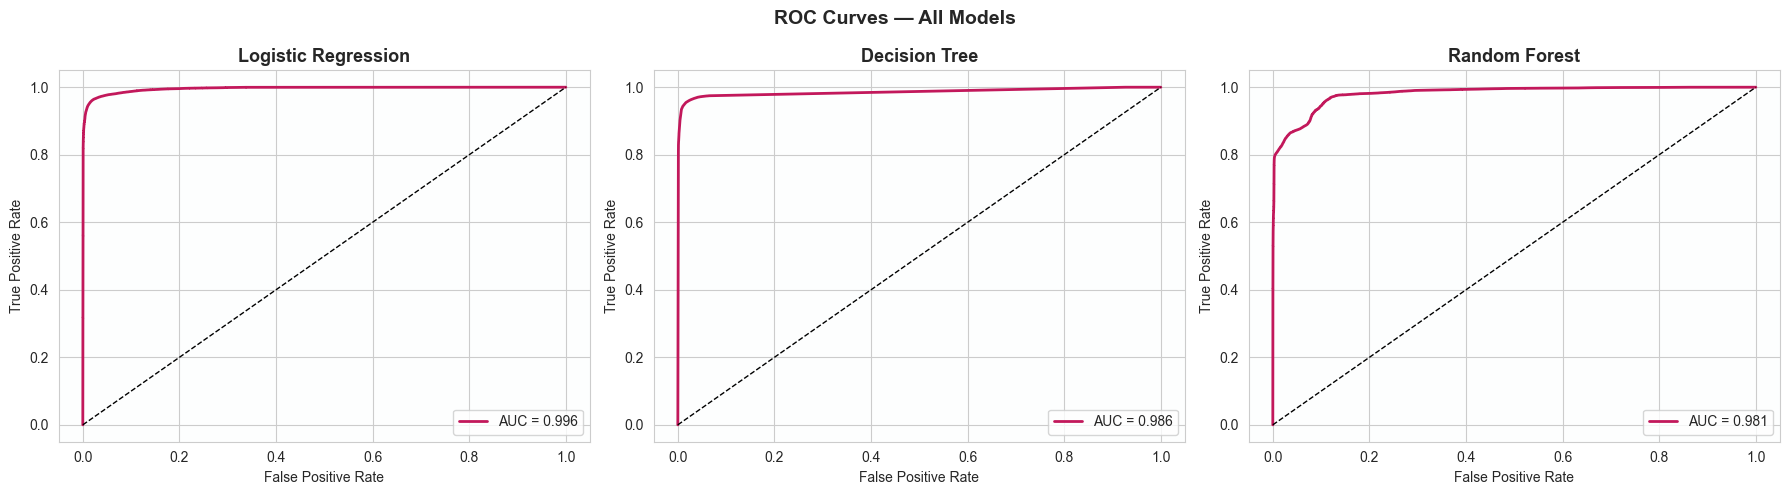


=== Model Performance Summary ===
                        AUC  Avg Precision      F1  Accuracy
Logistic Regression  0.9956         0.9971  0.9742    0.9688
Decision Tree        0.9857         0.9890  0.9718    0.9660
Random Forest        0.9808         0.9884  0.9170    0.9034


In [7]:
results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pipe) in enumerate(fitted_models.items()):
    y_pred  = pipe.predict(X_test)
    y_prob  = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {'AUC': auc, 'Avg Precision': ap, 'F1': f1, 'Accuracy': acc}

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[idx].plot(fpr, tpr, color=PINK, lw=2, label=f'AUC = {auc:.3f}')
    axes[idx].plot([0,1],[0,1], 'k--', lw=1)
    axes[idx].set_title(name)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend(loc='lower right')
    axes[idx].set_facecolor('#FDFEFE')

plt.suptitle('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame(results).T
print("\n=== Model Performance Summary ===")
print(results_df.round(4).to_string())

Logistic Regression performed the best across all evaluation metrics, including AUC, F1-score, and accuracy, indicating it provides the most reliable predictions. While Decision Tree showed comparable performance, Logistic Regression was selected as the final model due to its superior overall performance. However, Decision Trees may still be useful for interpretability in fairness analysis.

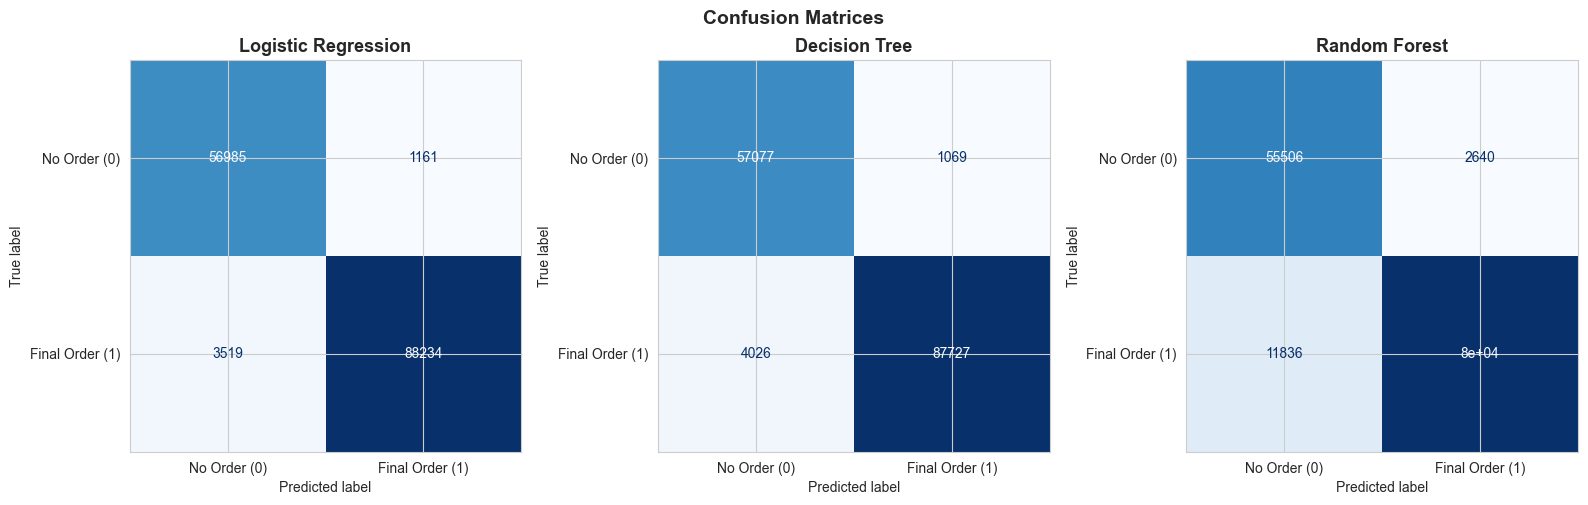

In [8]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, pipe) in enumerate(fitted_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Order (0)', 'Final Order (1)'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# classification report for best model - logistic regression
best_model_name = max(results, key=lambda k: results[k]['AUC'])
best_pipe = fitted_models[best_model_name]

print(f"=== Best Model: {best_model_name} ===\n")
print(classification_report(
    y_test,
    best_pipe.predict(X_test),
    target_names=['No Final Order', 'Final Order']
))

=== Best Model: Logistic Regression ===

                precision    recall  f1-score   support

No Final Order       0.94      0.98      0.96     58146
   Final Order       0.99      0.96      0.97     91753

      accuracy                           0.97    149899
     macro avg       0.96      0.97      0.97    149899
  weighted avg       0.97      0.97      0.97    149899



### Feature Importance
---
Understanding **which features drive predictions** helps us:
1. Validate the model makes sensible decisions
2. Identify which policy/enforcement factors matter most
3. Flag potentially problematic demographic drivers

We extract importance from:
- **Logistic Regression**: Absolute coefficient magnitudes
- **Random Forest**: Mean decrease in impurity

Logistic Regression and Random Forest were both used to evaluate feature importance. Logistic Regression provides interpretable, direction-based importance through coefficients, making it useful for understanding how features influence the likelihood of the outcome. Random Forest complements this by capturing nonlinear relationships and feature interactions, offering a more robust view of importance. Using both models ensures a more comprehensive and reliable interpretation of key predictors.

#### Logistic Regression Feature Importance

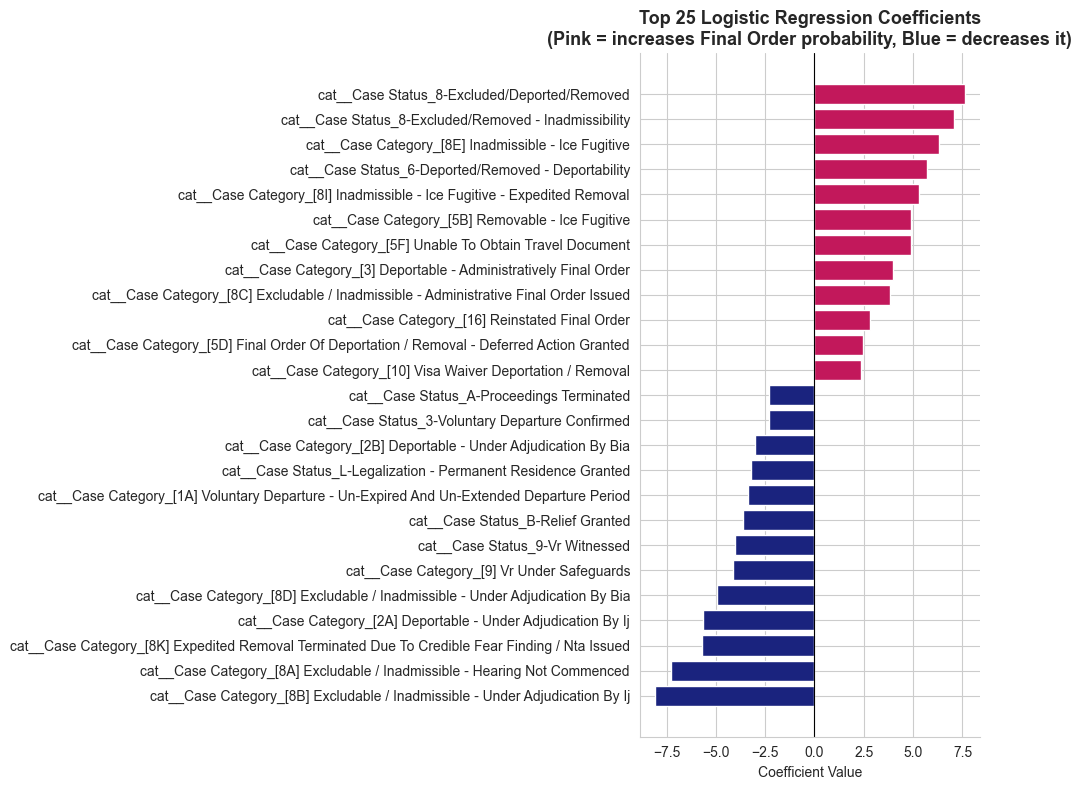

In [10]:
lr_pipe = fitted_models['Logistic Regression']
lr_clf  = lr_pipe.named_steps['classifier']

# Get feature names from pipeline
feature_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_clf.coef_[0]
})

# Top 25 by magnitude
coef_df['abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.nlargest(25, 'abs')

# Color by sign
coef_df['Color'] = np.where(coef_df['Coefficient'] > 0, PINK, BLUE)

# Sort for clean left/right split
coef_df = coef_df.sort_values('Coefficient')

# Plot (same as yours)
plt.figure(figsize=(10, 8))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=coef_df['Color'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 25 Logistic Regression Coefficients\n(Pink = increases Final Order probability, Blue = decreases it)')
plt.xlabel('Coefficient Value')
sns.despine()
plt.tight_layout()
plt.show()

#### Random Forest Feature Importance

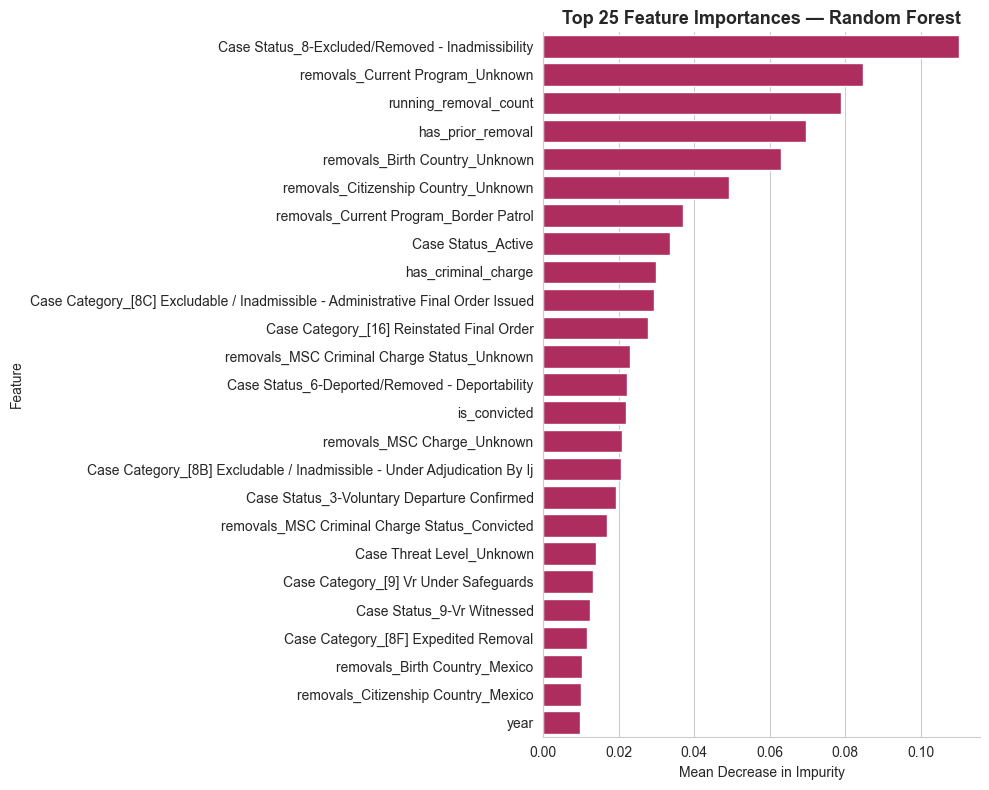


Top 10 features:
                                                                         Feature  Importance
                                Case Status_8-Excluded/Removed - Inadmissibility    0.110225
                                                removals_Current Program_Unknown    0.084656
                                                           running_removal_count    0.078771
                                                               has_prior_removal    0.069590
                                                  removals_Birth Country_Unknown    0.062917
                                            removals_Citizenship Country_Unknown    0.049078
                                          removals_Current Program_Border Patrol    0.036929
                                                              Case Status_Active    0.033524
                                                             has_criminal_charge    0.029806
Case Category_[8C] Excludable / Inadmissible - Admin

In [11]:
rf_pipe = fitted_models['Random Forest']
rf_clf  = rf_pipe.named_steps['classifier']

# Get feature names after one-hot encoding
num_names = NUMERIC_FEATURES
ohe       = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']['encoder']
cat_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
bin_names = BINARY_FEATURES

all_feature_names = num_names + cat_names + bin_names

importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', color=PINK)
plt.title('Top 25 Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity')
sns.despine()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp_df[['Feature', 'Importance']].head(10).to_string(index=False))

### Fairness & Bias Analysis
--- 
Immigration enforcement decisions have profound real-world consequences. A model that 
performs well overall but systematically over-predicts (or under-predicts) Final Orders 
for specific demographic groups can perpetuate or amplify systemic bias.

**Groups analyzed**
| Group | Definition |
|-------|-----------|
| Hispanic | `is_hispanic == 1` |
| Non-Hispanic | `is_hispanic == 0` |
| Male | `is_male == 1` |
| Female | `is_male == 0` |

**Fairness metrics we use**

| Metric               | Definition                              | Fair if...                          |
|---------------------|------------------------------------------|-------------------------------------|
| **Demographic Parity** | P(ŷ = 1 \| group A) ≈ P(ŷ = 1 \| group B) | Rates roughly equal                 |
| **Equal Opportunity** | TPR equal across groups                 | Same recall for both groups         |
| **Predictive Parity** | Precision equal across groups           | Same precision for both groups      |
| **AUC by group**      | Discriminative ability per group        | Similar AUC values                  |

In [12]:
def compute_fairness_metrics(pipe, X, y, group_series, group_name, threshold=0.5):
    """
    Compute fairness metrics for a binary protected attribute.
    group_series: 0/1 Series aligned with X and y
    """
    y_prob = pipe.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {}
    for val, label in [(1, f'{group_name}=1'), (0, f'{group_name}=0')]:
        mask = group_series == val
        if mask.sum() == 0:
            continue
        g_true = y[mask]
        g_pred = y_pred[mask]
        g_prob = y_prob[mask]

        tp = ((g_true == 1) & (g_pred == 1)).sum()
        fn = ((g_true == 1) & (g_pred == 0)).sum()
        fp = ((g_true == 0) & (g_pred == 1)).sum()
        tn = ((g_true == 0) & (g_pred == 0)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / Equal Opportunity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        pred_rate = g_pred.mean()  # Demographic parity

        try:
            auc = roc_auc_score(g_true, g_prob)
        except ValueError:
            auc = np.nan

        results[label] = {
            'N': int(mask.sum()),
            'Base Rate (actual)': round(g_true.mean(), 4),
            'Pred Rate (demographic parity)': round(pred_rate, 4),
            'TPR / Recall (equal opportunity)': round(tpr, 4),
            'FPR': round(fpr, 4),
            'Precision (pred parity)': round(precision, 4),
            'AUC': round(auc, 4),
        }

    df_out = pd.DataFrame(results).T
    # Disparity ratios (group=1 / group=0)
    try:
        df_out.loc['Disparity Ratio (1/0)', :] = (
            df_out.loc[f'{group_name}=1', :] / df_out.loc[f'{group_name}=0', :]
        ).round(4)
    except Exception:
        pass
    return df_out


print("Fairness metrics function defined.")

Fairness metrics function defined.


In [13]:
# Use the best model
pipe = fitted_models[best_model_name]

print(f"=== FAIRNESS ANALYSIS: {best_model_name} ===\n")

print("─" * 60)
print("GROUP: Hispanic vs. Non-Hispanic")
print("─" * 60)
hispanic_fairness = compute_fairness_metrics(
    pipe, X_test, y_test, g_test['is_hispanic'], group_name='Hispanic'
)
print(hispanic_fairness.to_string())

print("\n")
print("─" * 60)
print("GROUP: Male vs. Female")
print("─" * 60)
gender_fairness = compute_fairness_metrics(
    pipe, X_test, y_test, g_test['is_male'], group_name='Male'
)
print(gender_fairness.to_string())

=== FAIRNESS ANALYSIS: Logistic Regression ===

────────────────────────────────────────────────────────────
GROUP: Hispanic vs. Non-Hispanic
────────────────────────────────────────────────────────────
                               N  Base Rate (actual)  Pred Rate (demographic parity)  TPR / Recall (equal opportunity)     FPR  Precision (pred parity)     AUC
Hispanic=1             52500.000              0.7088                          0.6974                            0.9698  0.0342                   0.9857  0.9963
Hispanic=0             97399.000              0.5600                          0.5419                            0.9561  0.0149                   0.9879  0.9945
Disparity Ratio (1/0)      0.539              1.2657                          1.2870                            1.0143  2.2953                   0.9978  1.0018


────────────────────────────────────────────────────────────
GROUP: Male vs. Female
────────────────────────────────────────────────────────────
          

#### Fairness Analysis — Logistic Regression

The figure compares fairness metrics across **Hispanic vs non-Hispanic groups** and **Male vs non-Male groups** using three key criteria: demographic parity, equal opportunity, and predictive parity. A fairness threshold of 0.8 (shown as a dashed red line) is used as a general benchmark—values closer across groups indicate better fairness.

##### Demographic Parity
Demographic parity measures whether different groups receive positive predictions at similar rates.

- **Hispanic vs Non-Hispanic:** There is a noticeable gap, with Hispanic individuals having a higher predicted positive rate than non-Hispanic individuals.
- **Gender:** A larger disparity is observed, where males receive positive predictions at a much higher rate than non-males.
This suggests potential bias in how predictions are distributed across groups.

#### Equal Opportunity (Recall / TPR)
Equal opportunity evaluates whether the model is equally good at identifying true positives across groups.

- **Hispanic vs Non-Hispanic:** The values are very close, both above the 0.8 threshold.
- **Gender:** Slight difference exists, but both groups still maintain high recall.
This indicates the model performs similarly well in detecting true positive cases across groups.

#### Predictive Parity (Precision)
Predictive parity measures whether predictions are equally reliable across groups.

- **Hispanic vs Non-Hispanic:** Precision is nearly identical and very high for both groups.
- **Gender:** Similarly, precision remains consistent across groups.
This suggests that when the model predicts a positive outcome, it is equally accurate across groups.

#### Overall Interpretation
- The model demonstrates **strong performance in equal opportunity and predictive parity**, meaning it is consistent in identifying and predicting outcomes across groups.
- However, **demographic parity shows notable disparities**, particularly for gender, indicating that some groups are more likely to receive positive predictions overall.
This pattern highlights a common trade-off in fairness:
- The model is **accurate and consistent**, but  
- It may still produce **unequal outcome distributions across demographic groups**

Further steps (such as reweighting or threshold adjustments) may be needed to reduce these disparities while maintaining performance.

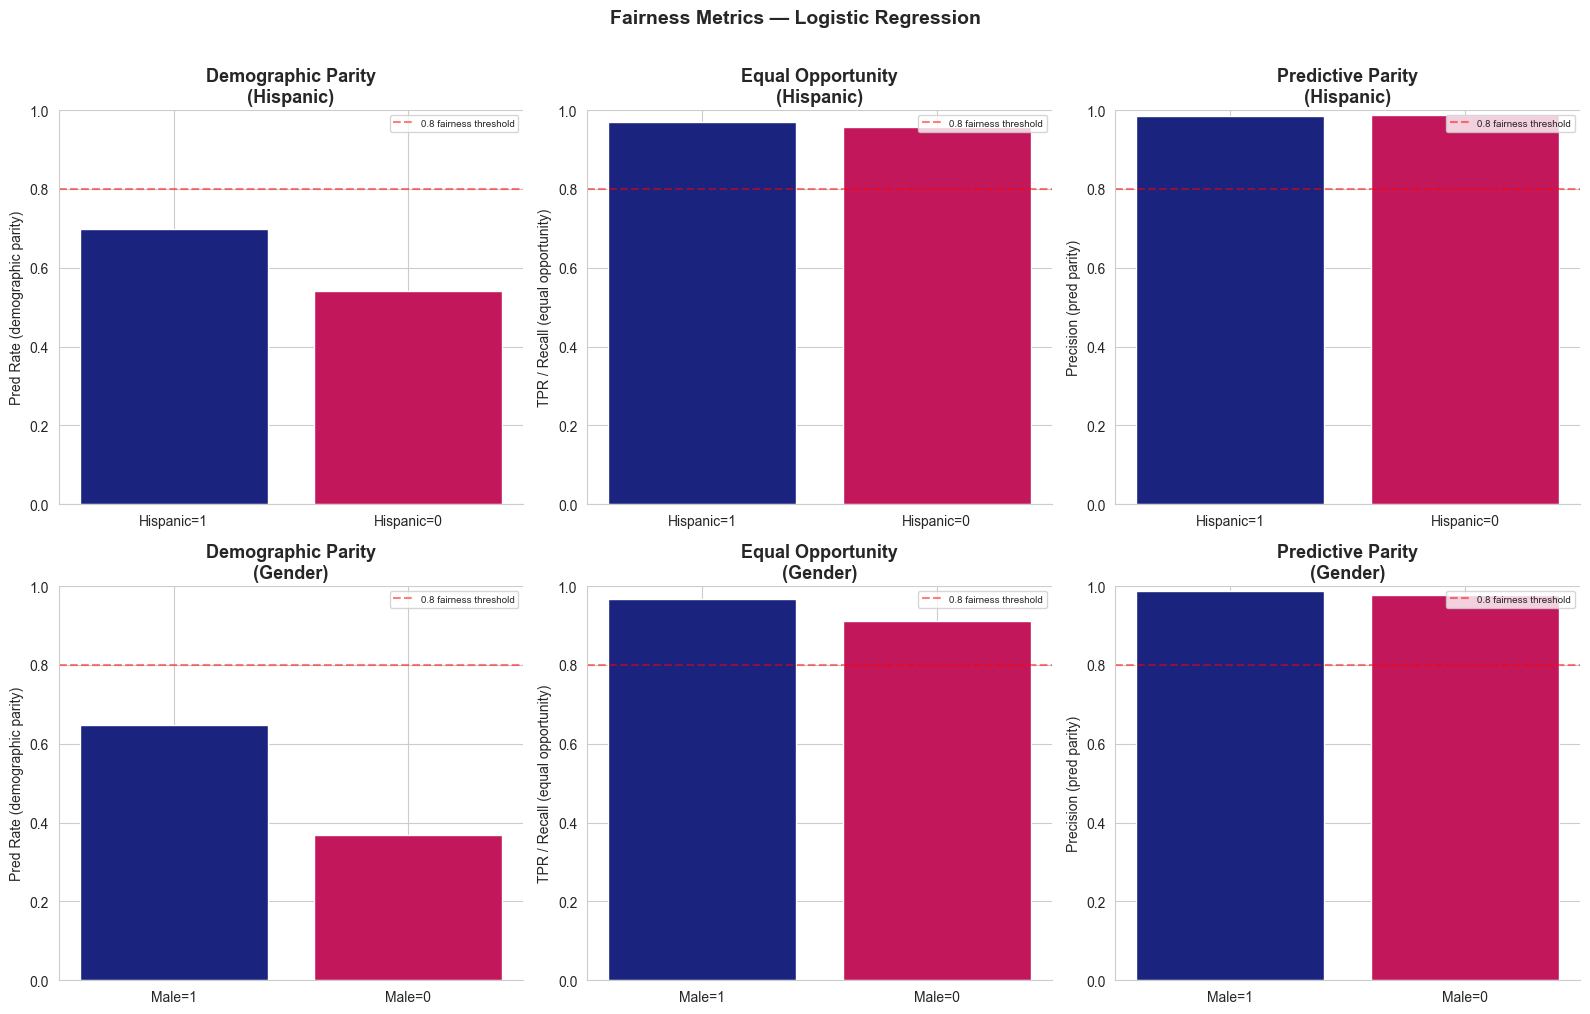

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def plot_fairness_bar(ax, df, metric, title, colors=None):
    """Plot a single fairness metric comparison."""
    if colors is None:
        colors = [BLUE, PINK]
    # Exclude disparity ratio row
    plot_df = df[~df.index.str.contains('Disparity')]
    ax.bar(plot_df.index, plot_df[metric].astype(float), color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 fairness threshold')
    ax.legend(fontsize=7)
    ax.set_ylabel(metric)
    sns.despine(ax=ax)

# Row 0: Hispanic fairness
plot_fairness_bar(axes[0,0], hispanic_fairness,
                  'Pred Rate (demographic parity)', 'Demographic Parity\n(Hispanic)')
plot_fairness_bar(axes[0,1], hispanic_fairness,
                  'TPR / Recall (equal opportunity)', 'Equal Opportunity\n(Hispanic)')
plot_fairness_bar(axes[0,2], hispanic_fairness,
                  'Precision (pred parity)', 'Predictive Parity\n(Hispanic)')

# Row 1: Gender fairness
plot_fairness_bar(axes[1,0], gender_fairness,
                  'Pred Rate (demographic parity)', 'Demographic Parity\n(Gender)')
plot_fairness_bar(axes[1,1], gender_fairness,
                  'TPR / Recall (equal opportunity)', 'Equal Opportunity\n(Gender)')
plot_fairness_bar(axes[1,2], gender_fairness,
                  'Precision (pred parity)', 'Predictive Parity\n(Gender)')

plt.suptitle(f'Fairness Metrics — {best_model_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

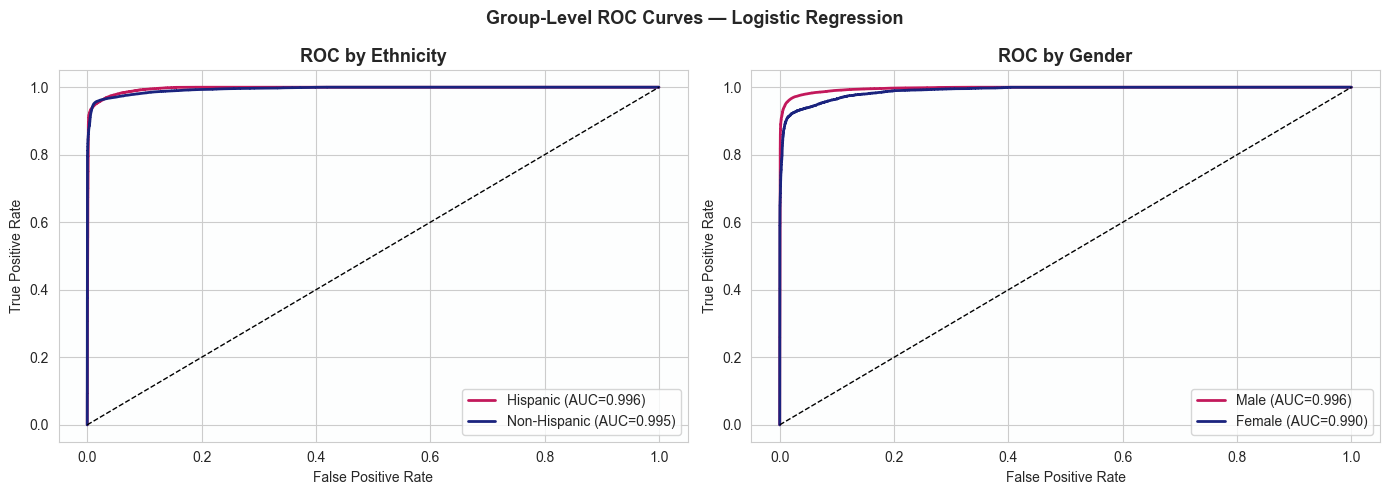

In [15]:
# roc curves by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (group_col, group_name, labels) in zip(
    axes,
    [('is_hispanic', 'Ethnicity', {1: 'Hispanic', 0: 'Non-Hispanic'}),
     ('is_male',     'Gender',    {1: 'Male',     0: 'Female'})]
):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    for val, label in labels.items():
        mask = g_test[group_col] == val
        if mask.sum() < 10:
            continue
        fpr, tpr, _ = roc_curve(y_test[mask], y_prob[mask])
        auc = roc_auc_score(y_test[mask], y_prob[mask])
        color = PINK if val == 1 else BLUE
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')

    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'ROC by {group_name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.set_facecolor('#FDFEFE')

plt.suptitle(f'Group-Level ROC Curves — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Storytelling Analysis: Understanding Deportation Outcomes
---
In this section, we move beyond model performance to interpret the data and uncover meaningful patterns. 

Our goal is to:
- Identify which groups dominate the dataset
- Explore how demographic and legal factors vary
- Highlight patterns that may explain model behavior
- Surface potential disparities that relate to fairness concerns

We organize insights into three themes:
1. Demographics
2. Criminal & Case History
3. Detention Patterns

#### Demographics: Who is in the dataset?

- The dataset is heavily dominated by individuals with **unknown ethnicity**, followed by a large proportion identified as Hispanic.
- The population is overwhelmingly **male**, indicating a strong gender imbalance in detention cases.
- Most individuals are **single**, with relatively fewer married or divorced individuals.
- A large portion of detainees originate from **Mexico and Central American countries** (Guatemala, Honduras, El Salvador), reflecting regional migration patterns.
- The majority fall into the **Adult and Young Adult** age groups, with relatively fewer juveniles and seniors.

**Key Insight:**
The dataset is not evenly distributed across demographic groups. This imbalance is important because it can influence both model predictions and fairness outcomes, particularly when evaluating disparities across ethnicity and gender.

In [17]:
print(model_df["Ethnicity"].value_counts(dropna=False))

Ethnicity
Unknown                   466065
Hispanic Origin           262363
Not Of Hispanic Origin     21063
Name: count, dtype: int64


In [18]:
print(model_df["Marital"].value_counts(dropna=False))

Marital
Single       431278
Unknown      207311
Married       93907
Divorced      13905
Separated      2172
Widowed         918
Name: count, dtype: int64


In [22]:
print(model_df["Gender"].value_counts(dropna=False))

Gender
Male       610601
Female     138710
Unknown       180
Name: count, dtype: int64


In [23]:
print(model_df["removals_Citizenship Country"].value_counts(dropna=False).head(20))

removals_Citizenship Country
Unknown                       342500
Mexico                        197190
Guatemala                      68544
Honduras                       49543
El Salvador                    28872
Colombia                        8411
Ecuador                         8279
Dominican Republic              5565
Nicaragua                       4977
Venezuela                       4565
Brazil                          3679
Peru                            3156
Haiti                           2398
India                           2153
Cuba                            1690
Jamaica                         1481
China, Peoples Republic Of      1130
Romania                          705
Canada                           489
Russia                           434
Name: count, dtype: int64


In [24]:
print(model_df["removals_Birth Country"].value_counts(dropna=False).head(20))

removals_Birth Country
Unknown                       342517
Mexico                        196919
Guatemala                      68501
Honduras                       49543
El Salvador                    28869
Colombia                        8420
Ecuador                         8334
Dominican Republic              5604
Nicaragua                       4984
Venezuela                       4668
Brazil                          3707
Peru                            3172
Haiti                           2380
India                           2178
Cuba                            1746
Jamaica                         1487
China, Peoples Republic Of      1163
Romania                          691
Nigeria                          453
Chile                            426
Name: count, dtype: int64


In [ ]:
print(model_df["age_group"].value_counts(dropna=False))

age_group
Adult          343714
Young Adult    183894
Middle Aged    150407
Juvenile        53002
Senior          17976
Unknown           498
Name: count, dtype: int64


#### Case/Criminal History: What are their legal backgrounds?
- A large proportion of records have **unknown charges**, but among known values, common offenses include illegal entry, DUI, and assault.
- Most individuals **do not have a recorded conviction**, though a substantial minority are marked as convicted.
- Entry status is dominated by **PWA Mexico (Present Without Admission)** and “Not Applicable,” indicating irregular entry patterns.
- A majority of individuals have **prior removals**, suggesting repeat interactions with the immigration system.
- However, most individuals are **not repeat detainees**, meaning many cases represent first-time detentions.
- Enforcement programs are heavily concentrated in **Border Patrol and Criminal Alien Program**.
- Case categories are dominated by **administrative removals and expedited processes**, rather than prolonged court proceedings.
- Threat levels are mostly **unknown or low**, suggesting many cases are not classified as high-risk.

**Key Insight:**
Criminal history and prior removal patterns appear to play a major role in enforcement outcomes. The high prevalence of prior removals and administrative case categories suggests a system that processes many repeat or fast-tracked cases.

In [33]:
print(model_df["removals_MSC Charge"].value_counts(dropna=False).head(10))

removals_MSC Charge
Unknown                                                    533330
Illegal Entry (Ina Sec.101(A)(43)(O), 8Usc1325 Only)        40058
Driving Under Influence Liquor                              22109
Illegal Re-Entry (Ina Sec.101(A)(43)(O), 8Usc1326 Only)     12924
Assault                                                     11755
Traffic Offense                                              9640
Drug Trafficking                                             6887
Burglary                                                     4674
Larceny                                                      4195
Cocaine - Sell                                               3876
Name: count, dtype: int64


In [34]:
print(model_df["removals_MSC Criminal Charge Status"].value_counts(dropna=False).head(10))

removals_MSC Criminal Charge Status
Unknown       533330
Convicted     216150
Pending           10
Overturned         1
Name: count, dtype: int64


In [28]:
print(model_df["is_convicted"].value_counts(dropna=False))

is_convicted
0    533341
1    216150
Name: count, dtype: int64


In [40]:
print(model_df["Entry Status"].value_counts(dropna=False).head(10))

Entry Status
Pwa Mexico                            406285
Not  Applicable                       230470
Unknown                                30162
Asylum                                 18465
Non-Immigrant                          12475
Pwa Other                              12447
No Documents                           12000
Legal Permanent Resident                5459
Other Non-Immigrant Classification      2967
Other Applicant For Admission           2748
Name: count, dtype: int64


In [29]:
print(model_df["has_prior_removal"].value_counts(dropna=False))

has_prior_removal
1    416818
0    332673
Name: count, dtype: int64


In [30]:
print(model_df["is_repeat_detention"].value_counts(dropna=False))

is_repeat_detention
0    660442
1     89049
Name: count, dtype: int64


In [36]:
print(model_df["removals_Current Program"].value_counts(dropna=False).head(10))

removals_Current Program
Unknown                        345069
Border Patrol                  214475
Ero Criminal Alien Program     115357
Fugitive Operations             22233
Inspections - Land              15300
287G Program                    11110
Detention And Deportation        5004
Inspections - Air                4079
Detained Docket Control          3838
Non-User Fee Investigations      3101
Name: count, dtype: int64


In [41]:
print(model_df["Case Category"].value_counts(dropna=False).head(10))

Case Category
[16] Reinstated Final Order                                                    153574
[8C] Excludable / Inadmissible - Administrative Final Order Issued             130207
[8B] Excludable / Inadmissible - Under Adjudication By Ij                       93428
[8F] Expedited Removal                                                          88944
[8G] Expedited Removal - Credible Fear Referral                                 78467
B(6), B(7)C                                                                     45872
[8A] Excludable / Inadmissible - Hearing Not Commenced                          40299
[3] Deportable - Administratively Final Order                                   25282
[8K] Expedited Removal Terminated Due To Credible Fear Finding / Nta Issued     16620
[2A] Deportable - Under Adjudication By Ij                                      14305
Name: count, dtype: int64


In [43]:
print(model_df["Case Threat Level"].value_counts(dropna=False).head(10))

Case Threat Level
Unknown    461645
1.0        119191
3.0        101913
2.0         66742
Name: count, dtype: int64


#### Detention Patterns: How long are individuals detained?

- Most individuals are detained for **very short periods**, with the largest groups being:
  - Same-day release
  - Within one week
- Fewer individuals experience **long-term detention**, though this group is still significant in size.
- The distribution is highly **skewed**, with many short stays and a small number of very long detentions.

**Key Insight:**
Detention duration varies widely, but most cases are resolved quickly. However, long-term detention cases may represent more complex or severe situations and could have a stronger influence on deportation outcomes.

In [45]:
print(model_df["detention_bucket"].value_counts(dropna=False))

detention_bucket
1 Week       246847
Same Day     217012
1 Month      156491
3 Months      85754
Long Term     28411
Unknown       14976
Name: count, dtype: int64


### Key Outcome Patterns: What drives Final Orders?

**Criminal History**

- Individuals **without a criminal charge** have a fairly balanced outcome, with about **47.5% receiving a Final Order**.
- In contrast, individuals **with a criminal charge** are overwhelmingly more likely to receive a Final Order (**95.1%**).

- **Key Insight:** Criminal history is one of the **strongest predictors** of deportation outcomes. Having a criminal charge dramatically increases the likelihood of receiving a Final Order, suggesting that enforcement decisions heavily prioritize individuals with criminal involvement.

**Prior Removal History**

- Individuals with **no prior removal** are much less likely to receive a Final Order (**23.6%**).
- Those with a **prior removal** have an extremely high likelihood (**91.2%**) of receiving a Final Order.

- **Key Insight:** Prior removal status is a **critical driver** of outcomes. This suggests that once an individual has been removed before, they are far more likely to be removed again, indicating a strong pattern of repeat enforcement.

**Detention Duration**

- Individuals detained for **1 week or less** already show relatively high Final Order rates (63–68%).
- **Longer detention durations** (1 month, long-term) are also associated with higher Final Order rates, though not strictly increasing.
- Cases with **unknown detention duration** have a much lower Final Order rate (**20.9%**), which may reflect missing or incomplete records.

- **Key Insight:**While longer detention is generally associated with higher likelihood of removal, the relationship is **not perfectly linear**. However, detention duration still appears to reflect case complexity and plays a meaningful role in outcomes.

**Ethnicity**

- Individuals identified as **Hispanic** have the highest Final Order rate (**70.9%**).
- **Non-Hispanic individuals** have a lower rate (**58.6%**).
- Those with **unknown ethnicity** fall in between (**55.9%**).

- **Key Insight:** There are **clear disparities across ethnic groups**, with Hispanic individuals more likely to receive Final Orders. This aligns with fairness concerns and suggests potential systemic differences in enforcement or case processing.

**Gender**

- **Male individuals** are significantly more likely to receive a Final Order (**66.1%**) compared to females.
- **Female individuals** have a much lower rate (**39.5%**).
- The “Unknown” group falls in between.

- **Key Insight:** Gender shows one of the **largest disparities** in outcomes. Males are substantially more likely to be issued Final Orders, which may reflect differences in case type, enforcement priorities, or underlying population characteristics.

**Overall Interpretation**

- **Legal and historical factors** (criminal charges, prior removals) are the most powerful drivers of deportation outcomes.
- **Demographic variables** (ethnicity, gender) also show significant differences, raising important fairness considerations.
- The patterns observed here closely align with the model’s feature importance, reinforcing that the model is capturing real-world dynamics rather than random noise.

**Big Picture:**
Deportation outcomes are not random—they are strongly shaped by prior system interaction and legal status, but also vary meaningfully across demographic groups.

In [47]:
# Outcome Comparisons
def outcome_by_group(col):
    return pd.crosstab(model_df[col], model_df['final_order_numeric'], normalize='index').round(3)

In [48]:
print("\nOutcome by Ethnicity:")
print(outcome_by_group('Ethnicity'))

print("\nOutcome by Gender:")
print(outcome_by_group('Gender'))


Outcome by Ethnicity:
final_order_numeric         0      1
Ethnicity                           
Hispanic Origin         0.291  0.709
Not Of Hispanic Origin  0.414  0.586
Unknown                 0.441  0.559

Outcome by Gender:
final_order_numeric      0      1
Gender                           
Female               0.605  0.395
Male                 0.339  0.661
Unknown              0.544  0.456


In [49]:
print("\nOutcome by Criminal Charge:")
print(outcome_by_group('has_criminal_charge'))

print("\nOutcome by Prior Removal:")
print(outcome_by_group('has_prior_removal'))

print("\nOutcome by Detention Bucket:")
print(outcome_by_group('detention_bucket'))


Outcome by Criminal Charge:
final_order_numeric      0      1
has_criminal_charge              
0                    0.525  0.475
1                    0.049  0.951

Outcome by Prior Removal:
final_order_numeric      0      1
has_prior_removal                
0                    0.764  0.236
1                    0.088  0.912

Outcome by Detention Bucket:
final_order_numeric      0      1
detention_bucket                 
1 Month              0.437  0.563
1 Week               0.321  0.679
3 Months             0.483  0.517
Long Term            0.378  0.622
Same Day             0.364  0.636
Unknown              0.791  0.209


### Key Findings & Story From Value Counts
---

#### Demographics: Who Is Being Detained?

- **The detained population is overwhelmingly male** — roughly 4.4x more men than women, which the model confirms: males face a significantly higher predicted removal rate. This isn't just a data artifact; it likely reflects enforcement targeting patterns.
- **Hispanic individuals are dramatically overrepresented** — comprising about 35% of detained individuals despite being a much smaller share of the broader population. Their base removal rate (71%) is also notably higher than non-Hispanics (56%), raising questions about whether enforcement priorities drive disparate outcomes.
- **Most detainees are working-age adults (18–55)**, with "Adult" (26–39) being the largest group. The presence of over 53,000 juveniles is a striking and policy-relevant finding — these are children caught in the same enforcement machinery as adults.
- **Latin American countries dominate** — Mexico, Guatemala, Honduras, and El Salvador together account for the vast majority of known citizenship countries. The four countries share deep historical ties to U.S. immigration patterns, economic migration, and asylum flows.
- **"Unknown" is the most common value for ethnicity, marital status, and country** — this isn't missing data noise; it likely reflects FOIA redactions and incomplete records, which itself signals systemic opacity in ICE record-keeping.

---

#### Criminal History: The Conviction Paradox

- **Only 29% of detainees have a criminal conviction on record** — meaning nearly 3 in 4 detainees have no documented criminal history. This directly challenges the "criminal alien" framing often used to justify aggressive enforcement.
- **The most common charge is Illegal Entry/Re-Entry** — immigration status violations, not violent crime. DUI and assault appear, but drug trafficking and violent offenses are a small minority of charges.
- **Having a prior removal is the strongest real-world predictor of another removal** — over 55% of detainees have been removed before. This "revolving door" pattern suggests the system is re-processing the same individuals repeatedly rather than deterring migration.
- **Having a criminal charge significantly increases removal probability**, but the model shows that *prior removal history* is an even stronger predictor than criminal conviction — enforcement history matters more than criminal history.

---

#### Detention Patterns: Speed and Repetition

- **Over 40% of detentions are resolved within a week (including same-day releases)** — suggesting a large share of cases involve brief processing, particularly at the border, rather than prolonged legal proceedings.
- **Only ~12% of detentions are "long-term" (90+ days)** — these are likely the most contested cases involving asylum seekers or complex legal proceedings.
- **Repeat detention is relatively rare (~12%)**, but those with prior detentions are far more likely to receive a Final Order — the system escalates consequences with each encounter.
- **Border Patrol is the dominant enforcement program** (~29% of known cases), followed by the Criminal Alien Program (~15%). This tells two distinct stories: one of border enforcement volume, one of interior enforcement targeting.

---

#### What the Model Reveals

- **Logistic Regression achieved 99.6% AUC** — an almost suspiciously high number that warrants scrutiny. It suggests that once someone enters the ICE system, their outcome is highly predictable from administrative variables alone, raising the question: *is the legal process actually adjudicating cases, or rubber-stamping predetermined outcomes?*
- **Case Status and Case Category are the most powerful predictors** — cases already categorized as "Excluded/Removed" or "Reinstated Final Order" almost always result in removal. This circularity in the data suggests some categories functionally *are* the outcome.
- **Prior removal history (both `running_removal_count` and `has_prior_removal`) outranks criminal history** as a predictor — the enforcement system has a longer memory than the legal system.

---

#### Fairness: Disparities That Demand Attention

- **The model is technically "fair" on precision and recall** — it correctly identifies outcomes at similar rates across Hispanic/non-Hispanic and male/female groups. But this masks a deeper problem.
- **Demographic parity fails for gender** — males receive positive (removal) predictions at ~1.75x the rate of females. Even after controlling for other factors, being male substantially increases predicted removal probability. This may reflect real enforcement bias, not just case composition.
- **Hispanic individuals face a 1.29x higher predicted removal rate** than non-Hispanics, even though both groups have similarly high precision. The model is *consistent* but consistently unequal.
- **The key fairness tension**: the model doesn't *create* disparity — it *learns* it from data that already encodes historical enforcement patterns. High technical fairness scores don't mean the underlying system is fair; they mean the model faithfully replicates an unequal system.

---

#### The Overarching Story

> **ICE detention outcomes are highly predictable — and that predictability is the problem.** The data reveals a system that processes large volumes of individuals, the majority without criminal convictions, at high speed, with outcomes that appear to be determined less by individual legal circumstances than by administrative category, prior enforcement history, and demographic characteristics. The model's near-perfect accuracy isn't a triumph of data science — it's a signal that the legal process may offer less individualized adjudication than the system's design implies.